<a href="https://colab.research.google.com/github/gs19891908-cmd/car_prices_gaurav_sharma_b10/blob/main/car_prices_GauravSharmaB10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Used Car Prices — Exploratory Data Analysis
**Assignment | Pandas Data Analysis**  
Dataset: `car_prices.csv`

Assignment By : Gaurav Sharma - B10

---
## 📦 Section 1: Data Ingestion & Quality Profiling

### 1.1 Load & Inspect

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
from google.colab import files
uploaded = files.upload()

Saving car_prices.csv to car_prices (1).csv


In [21]:
import io
df = pd.read_csv(io.BytesIO(uploaded['car_prices (1).csv']))
print("── First 5 Rows ──────────────────────────────")
display(df.head())

print("\n── Data Types & Non-Null Counts ──────────────")
print(df.info())

print(f"\nTotal Records : {len(df):,}")
print(f"Total Columns : {df.shape[1]}")

── First 5 Rows ──────────────────────────────


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.00,"16,639.00",white,black,kia motors america inc,"20,500.00","21,500.00",Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.00,"9,393.00",white,beige,kia motors america inc,"20,800.00","21,500.00",Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.00,"1,331.00",gray,black,financial services remarketing (lease),"31,900.00","30,000.00",Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.00,"14,282.00",white,black,volvo na rep/world omni,"27,500.00","27,750.00",Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.00,"2,641.00",gray,black,financial services remarketing (lease),"66,000.00","67,000.00",Thu Dec 18 2014 12:30:00 GMT-0800 (PST)



── Data Types & Non-Null Counts ──────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory u

### 1.2 Understanding the Data Structure

In [22]:
print(f"Shape  →  {df.shape[0]:,} rows  x  {df.shape[1]} columns\n")

print("── Column Names & Data Types ─────────────────")
print(df.dtypes.to_string())

Shape  →  558,837 rows  x  16 columns

── Column Names & Data Types ─────────────────
year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object


### 1.3 Missing & Anomaly Detection

In [23]:
# ── Null counts & percentages ──────────────────────────────────
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df     = pd.DataFrame({'Null Count': null_counts,
                            'Null %'    : null_pct})                .query('`Null Count` > 0')                .sort_values('Null %', ascending=False)

print("── Missing Values Summary ────────────────────")
display(null_df)

── Missing Values Summary ────────────────────


,Null Count,Null %
transmission,65352,11.69
body,13195,2.36
condition,11820,2.12
trim,10651,1.91
model,10399,1.86
make,10301,1.84
color,749,0.13
interior,749,0.13
odometer,94,0.02
mmr,38,0.01


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid')
print("Libraries loaded ✅")

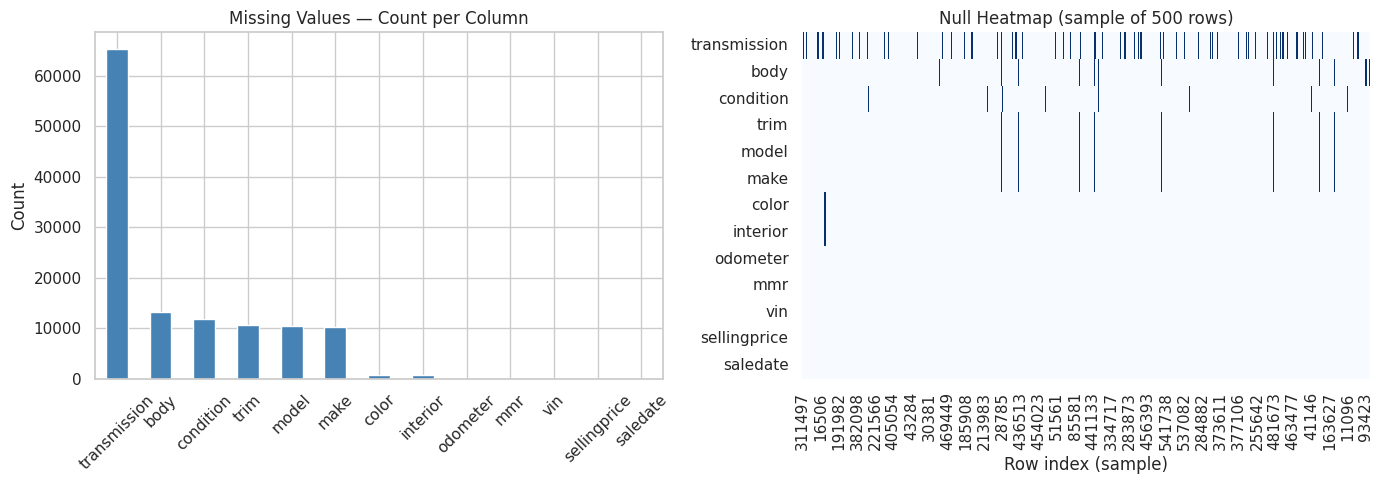

Chart saved ✅


In [24]:
# ── Bar chart of missing values ───────────────────────────────
if not null_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    null_df['Null Count'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Missing Values — Count per Column')
    axes[0].set_ylabel('Count'); axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=45)

    # Heatmap of nulls (sample for speed)
    sample = df[null_df.index].isnull().sample(min(500, len(df)), random_state=42)
    sns.heatmap(sample.T, cbar=False, ax=axes[1],
                cmap='Blues', yticklabels=True)
    axes[1].set_title('Null Heatmap (sample of 500 rows)')
    axes[1].set_xlabel('Row index (sample)')

    plt.tight_layout()
    plt.savefig('plot_missing_values.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Chart saved ✅")
else:
    print("No missing values found 🎉")

In [25]:
# ── Resolve nulls ─────────────────────────────────────────────
# Strategy:
#   Numeric  columns  → fill with MEDIAN  (robust to skew)
#   Object/category   → fill with MODE    (most frequent value)

for col in df.columns:
    missing_pct = df[col].isnull().mean() * 100
    if missing_pct == 0:
        continue
    if df[col].dtype in ['float64', 'int64']:
        fill_val = df[col].median()
        df[col].fillna(fill_val, inplace=True)
        print(f"  [{col}]  numeric  | {missing_pct:.1f}% nulls → filled with MEDIAN ({fill_val:,.2f})")
    else:
        fill_val = df[col].mode()[0]
        df[col].fillna(fill_val, inplace=True)
        print(f"  [{col}]  object   | {missing_pct:.1f}% nulls → filled with MODE  ('{fill_val}')")

print("\nRemaining nulls:", df.isnull().sum().sum())

  [make]  object   | 1.8% nulls → filled with MODE  ('Ford')
  [model]  object   | 1.9% nulls → filled with MODE  ('Altima')
  [trim]  object   | 1.9% nulls → filled with MODE  ('Base')
  [body]  object   | 2.4% nulls → filled with MODE  ('Sedan')
  [transmission]  object   | 11.7% nulls → filled with MODE  ('automatic')
  [vin]  object   | 0.0% nulls → filled with MODE  ('automatic')
  [condition]  numeric  | 2.1% nulls → filled with MEDIAN (35.00)
  [odometer]  numeric  | 0.0% nulls → filled with MEDIAN (52,254.00)
  [color]  object   | 0.1% nulls → filled with MODE  ('black')
  [interior]  object   | 0.1% nulls → filled with MODE  ('black')
  [mmr]  numeric  | 0.0% nulls → filled with MEDIAN (12,250.00)
  [sellingprice]  numeric  | 0.0% nulls → filled with MEDIAN (12,100.00)
  [saledate]  object   | 0.0% nulls → filled with MODE  ('Tue Feb 10 2015 01:30:00 GMT-0800 (PST)')

Remaining nulls: 0


In [26]:
# ── Duplicate Records ─────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count:,}")

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows after removing duplicates: {len(df):,}")

Duplicate rows found: 0
Rows after removing duplicates: 558,837


---
## 🔍 Section 2: DataFrame Queries

### 2.1 Average, Min & Max Car Price

In [30]:
price_col = 'sellingprice'

avg_price = df[price_col].mean()
min_price = df[price_col].min()
max_price = df[price_col].max()

print(f"Average Selling Price : ${avg_price:>12,.2f}")
print(f"Minimum Selling Price : ${min_price:>12,.2f}")
print(f"Maximum Selling Price : ${max_price:>12,.2f}")

Average Selling Price : $   13,611.33
Minimum Selling Price : $        1.00
Maximum Selling Price : $  230,000.00


### 2.2 All Unique Car Colors

In [31]:
unique_colors = sorted(df['color'].dropna().unique().tolist())
print(f"Total unique colors: {len(unique_colors)}")
print(unique_colors)

Total unique colors: 46
['11034', '1167', '12655', '14872', '15719', '16633', '18384', '18561', '20379', '20627', '2172', '2711', '2817', '2846', '339', '4802', '5001', '5705', '6158', '6388', '6864', '721', '9410', '9562', '9837', '9887', 'beige', 'black', 'blue', 'brown', 'burgundy', 'charcoal', 'gold', 'gray', 'green', 'lime', 'off-white', 'orange', 'pink', 'purple', 'red', 'silver', 'turquoise', 'white', 'yellow', '—']


### 2.3 Unique Car Brands & Models

In [32]:
n_brands = df['make'].nunique()
n_models = df['model'].nunique()
print(f"Unique Brands (make) : {n_brands}")
print(f"Unique Models        : {n_models}")

Unique Brands (make) : 96
Unique Models        : 973


### 2.4 Cars with Selling Price > $165,000

In [33]:
expensive = df[df[price_col] > 165_000]
print(f"Cars priced above $165,000: {len(expensive):,}")
display(expensive.head(10))

Cars priced above $165,000: 7


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.00,"14,316.00",black,beige,braman motorcars,"154,000.00","169,500.00",Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.00,"27,802.00",green,tan,ford-lincoln dealer program,"22,800.00","230,000.00",Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.00,"5,277.00",white,white,mercedes-benz usa,"170,000.00","173,000.00",Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.00,"5,215.00",white,tan,financial services remarketing (bmw int),"166,000.00","167,000.00",Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.00,"7,852.00",white,beige,flag/landrover southpointe,"178,000.00","171,500.00",Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.00,"12,116.00",red,black,platinum motor cars,"182,000.00","183,000.00",Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.00,"11,832.00",white,black,bentley scottsdale,"164,000.00","169,000.00",Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


### 2.5 Top 5 Most Frequently Sold Car Models

In [34]:
top5_models = df['model'].value_counts().head(5)
print("Top 5 Most Sold Models:")
print(top5_models.to_string())

Top 5 Most Sold Models:
model
Altima    29748
F-150     14479
Fusion    12946
Camry     12545
Escape    11861


### 2.6 Average Selling Price by Brand (Make)

In [35]:
avg_by_make = (df.groupby('make')[price_col]
                 .mean()
                 .sort_values(ascending=False)
                 .round(2))
print("Average Selling Price by Brand:")
display(avg_by_make.reset_index().rename(columns={price_col: 'avg_price'}))

Average Selling Price by Brand:


,make,avg_price
0,Rolls-Royce,"153,488.24"
1,Ferrari,"127,210.53"
2,Lamborghini,"112,625.00"
3,Bentley,"74,367.67"
4,airstream,"71,000.00"
...,...,...
91,dodge tk,550.00
92,Geo,528.95
93,dot,500.00
94,ford truck,483.33


### 2.7 Minimum Selling Price for Each Interior

In [36]:
min_by_interior = (df.groupby('interior')[price_col]
                     .min()
                     .sort_values()
                     .reset_index()
                     .rename(columns={price_col: 'min_price'}))
display(min_by_interior)

,interior,min_price
0,black,1.00
1,gray,1.00
2,green,100.00
3,beige,100.00
4,tan,100.00
5,blue,150.00
6,silver,150.00
7,—,150.00
8,burgundy,175.00
9,red,200.00


### 2.8 Highest Odometer Reading per Year (Descending)

In [37]:
max_odo = (df.groupby('year')['odometer']
             .max()
             .sort_values(ascending=False)
             .reset_index()
             .rename(columns={'odometer': 'max_odometer'}))
display(max_odo)

,year,max_odometer
0,1997,"999,999.00"
1,1996,"999,999.00"
2,2014,"999,999.00"
3,2013,"999,999.00"
4,1998,"999,999.00"
5,1999,"999,999.00"
6,1993,"999,999.00"
7,2010,"999,999.00"
8,2009,"999,999.00"
9,2012,"999,999.00"


### 2.9 New Column: Car Age (as of 2025)

In [38]:
df['car_age'] = 2025 - df['year']
print("Car age column added ✅")
display(df[['year', 'car_age']].drop_duplicates().sort_values('year').head(10))

Car age column added ✅


,year,car_age
207920,1982,43
368682,1983,42
78404,1984,41
41335,1985,40
7731,1986,39
5267,1987,38
60242,1988,37
5271,1989,36
7720,1990,35
5289,1991,34


### 2.10 Cars with Condition ≥ 48 AND Odometer > 90,000

In [ ]:
filtered = df[(df['condition'] >= 48) & (df['odometer'] > 90_000)]
print(f"Number of cars matching criteria: {len(filtered):,}")

### 2.11 State with Consistently Higher Prices for Newer Cars (Year > 2013)

In [39]:
newer = df[df['year'] > 2013]
state_avg = (newer.groupby('state')[price_col]
                   .agg(['mean', 'count'])
                   .rename(columns={'mean': 'avg_price', 'count': 'num_cars'})
                   .query('num_cars >= 10')          # at least 10 listings for reliability
                   .sort_values('avg_price', ascending=False))

print("Top 10 states by avg price (newer cars, year > 2013):")
display(state_avg.head(10))
print(f"\n🏆 State with consistently highest prices: {state_avg.index[0]}  "
      f"(avg ${state_avg['avg_price'].iloc[0]:,.0f})")

Top 10 states by avg price (newer cars, year > 2013):


,avg_price,num_cars
state,,
oh,"28,020.22",2755
ab,"25,204.26",141
nj,"24,237.06",3267
on,"22,962.56",1863
qc,"22,722.94",388
pa,"22,190.23",7173
tn,"21,841.68",5035
mi,"21,411.62",2050
ca,"20,951.32",9840



🏆 State with consistently highest prices: oh  (avg $28,020)


### 2.12 Best Value Makes in Top 20% Condition

In [40]:
threshold = df['condition'].quantile(0.80)
excellent = df[df['condition'] >= threshold]

value_makes = (excellent.groupby('make')[price_col]
                         .mean()
                         .sort_values()
                         .head(10)
                         .reset_index()
                         .rename(columns={price_col: 'avg_price'}))

print(f"Condition threshold for top 20%: {threshold}")
print("\nTop 10 Makes with Lowest Avg Price in Excellent Condition (Best Value):")
display(value_makes)

Condition threshold for top 20%: 43.0

Top 10 Makes with Lowest Avg Price in Excellent Condition (Best Value):


,make,avg_price
0,Isuzu,"1,125.00"
1,Oldsmobile,"1,910.00"
2,honda,"4,233.33"
3,Saturn,"5,700.41"
4,subaru,"6,200.00"
5,chrysler,"6,225.00"
6,smart,"6,835.76"
7,mazda,"7,275.00"
8,Pontiac,"7,686.82"
9,Saab,"7,711.11"


---
## 📊 Section 3: Data Visualization & Insights

### 3.1 Correlation Heatmap of Numerical Features

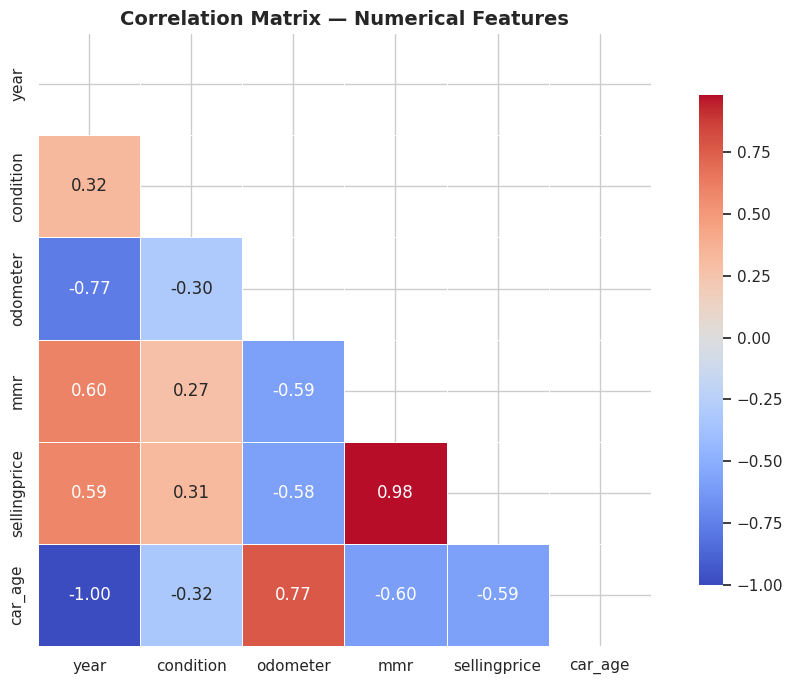


📌 Insight: Features closest to ±1.0 have strong linear relationship.


In [45]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Insight: Features closest to ±1.0 have strong linear relationship.")

### 3.2 Average Selling Price by Year

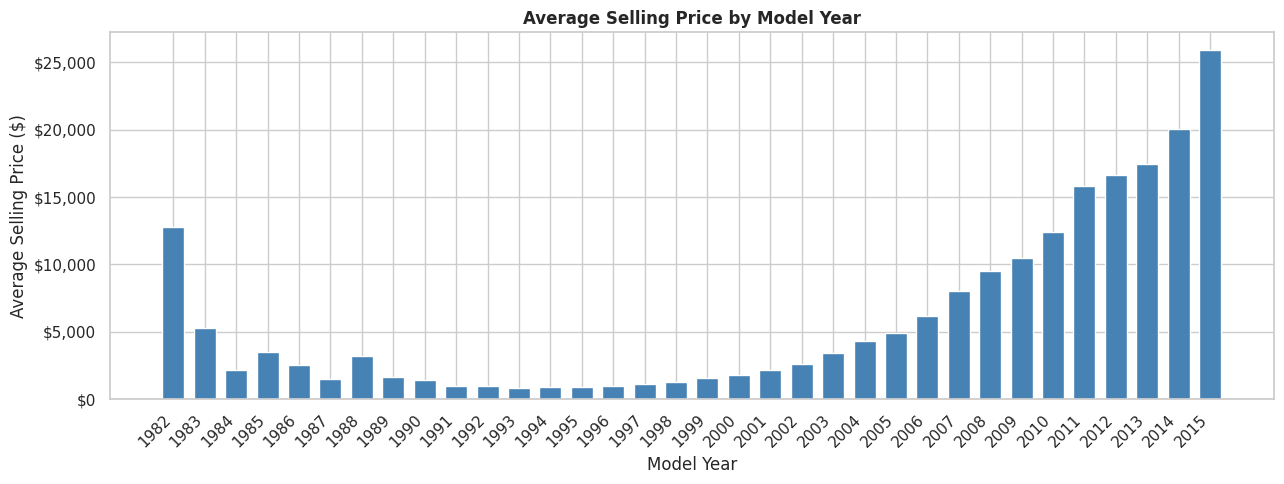


📌 Pattern: A bar chart is best here — we're comparing discrete year categories.
   Newer model years (post-2010) generally command higher prices.
   Very old cars (pre-1990) can also fetch higher prices due to classic/collector value.
   Mid-range years (2000–2008) tend to have the lowest average prices.



In [46]:
avg_by_year = (df.groupby('year')[price_col]
                 .mean()
                 .reset_index()
                 .sort_values('year'))

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(avg_by_year['year'].astype(str), avg_by_year[price_col],
       color='steelblue', edgecolor='white', width=0.7)
ax.set_title('Average Selling Price by Model Year', fontweight='bold')
ax.set_xlabel('Model Year')
ax.set_ylabel('Average Selling Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_price_by_year.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
📌 Pattern: A bar chart is best here — we're comparing discrete year categories.
   Newer model years (post-2010) generally command higher prices.
   Very old cars (pre-1990) can also fetch higher prices due to classic/collector value.
   Mid-range years (2000–2008) tend to have the lowest average prices.
""")

### 3.3 Average Selling Price by Odometer Reading

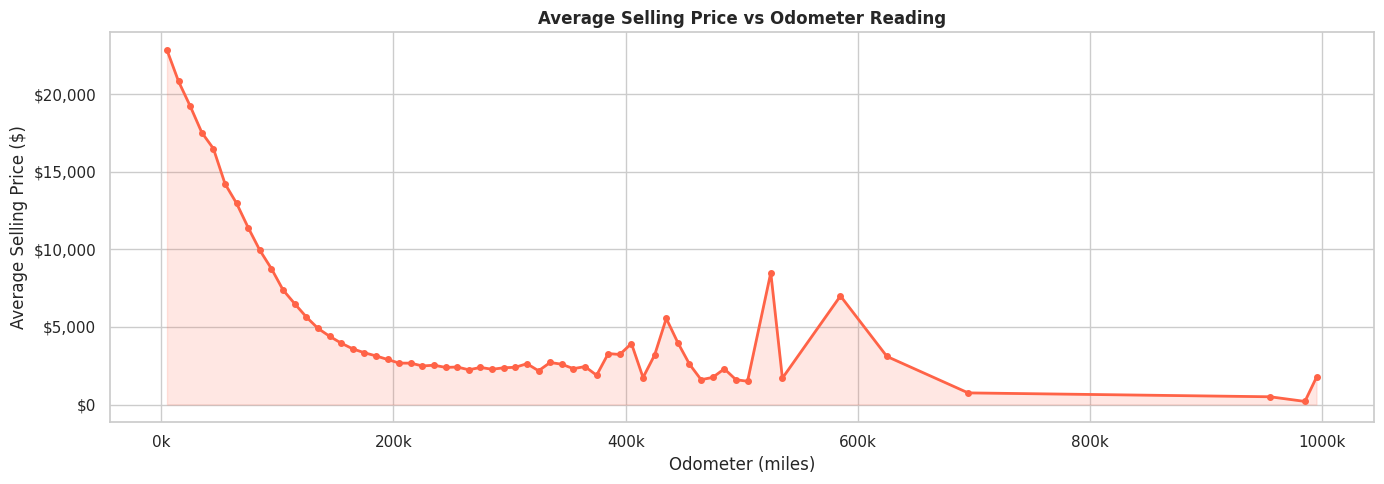


📌 Trend: Clear negative correlation — as odometer reading increases, selling price drops.
   High-mileage cars (>150k miles) sell significantly cheaper.
   Cars under 20k miles command a strong premium.



In [47]:
# Bin odometer into 10k-mile buckets
df['odo_bin'] = pd.cut(df['odometer'],
                       bins=range(0, int(df['odometer'].max()) + 10_001, 10_000),
                       right=False)
avg_by_odo = (df.groupby('odo_bin', observed=True)[price_col]
               .mean()
               .reset_index()
               .dropna())
avg_by_odo['odo_mid'] = avg_by_odo['odo_bin'].apply(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(avg_by_odo['odo_mid'], avg_by_odo[price_col],
        marker='o', color='tomato', linewidth=2, markersize=4)
ax.fill_between(avg_by_odo['odo_mid'], avg_by_odo[price_col], alpha=0.15, color='tomato')
ax.set_title('Average Selling Price vs Odometer Reading', fontweight='bold')
ax.set_xlabel('Odometer (miles)')
ax.set_ylabel('Average Selling Price ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_price_by_odometer.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
📌 Trend: Clear negative correlation — as odometer reading increases, selling price drops.
   High-mileage cars (>150k miles) sell significantly cheaper.
   Cars under 20k miles command a strong premium.
""")

### 3.4 Number of Cars Sold per State

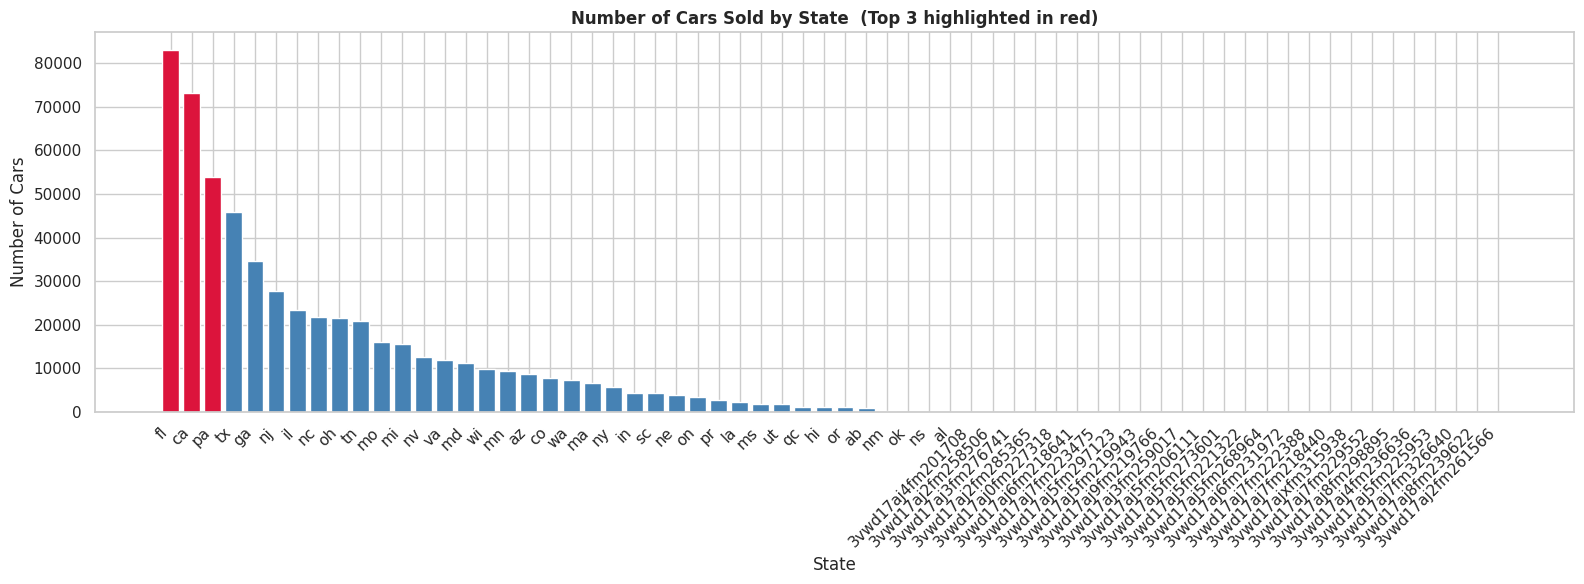

🏆 Top 3 Car Selling States:
   FL  →  82,945 cars
   CA  →  73,148 cars
   PA  →  53,907 cars


In [50]:
cars_by_state = df['state'].value_counts().reset_index()
cars_by_state.columns = ['state', 'count']

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['crimson' if i < 3 else 'steelblue' for i in range(len(cars_by_state))]
ax.bar(cars_by_state['state'], cars_by_state['count'],
       color=colors, edgecolor='white')
ax.set_title('Number of Cars Sold by State  (Top 3 highlighted in red)', fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Number of Cars')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_cars_by_state.png', dpi=120, bbox_inches='tight')
plt.show()

top3 = cars_by_state.head(3)
print("🏆 Top 3 Car Selling States:")
for _, row in top3.iterrows():
    print(f"   {row['state'].upper()}  →  {row['count']:,} cars")

### 3.5 Average Selling Price by Condition Score (Bins of 5)

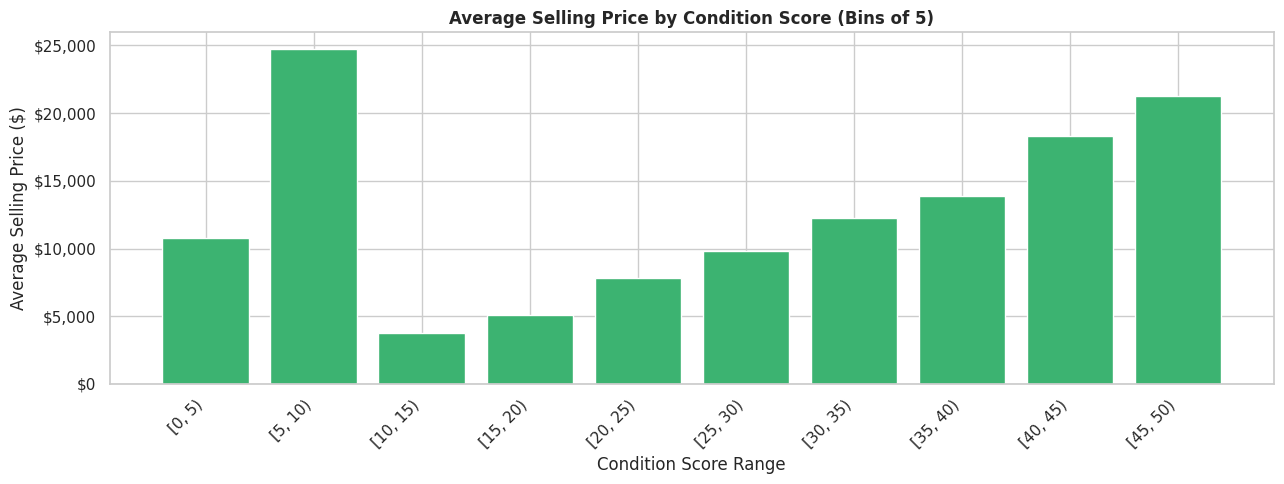


📌 Insights:
   • Higher condition scores correspond to higher average selling prices — as expected.
   • The price jump is most pronounced in the top condition bands (45–50+).
   • Cars in poor condition (0–15) sell at heavily discounted prices.
   • Mid-range condition (25–35) cars show moderate, relatively stable pricing.



In [51]:
cond_max = int(df['condition'].max()) + 5
bins5 = range(0, cond_max + 1, 5)
df['cond_bin5'] = pd.cut(df['condition'], bins=list(bins5), right=False)

avg_by_cond5 = (df.groupby('cond_bin5', observed=True)[price_col]
                  .mean()
                  .reset_index()
                  .dropna())

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(avg_by_cond5['cond_bin5'].astype(str),
       avg_by_cond5[price_col],
       color='mediumseagreen', edgecolor='white')
ax.set_title('Average Selling Price by Condition Score (Bins of 5)', fontweight='bold')
ax.set_xlabel('Condition Score Range')
ax.set_ylabel('Average Selling Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_price_by_condition5.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
📌 Insights:
   • Higher condition scores correspond to higher average selling prices — as expected.
   • The price jump is most pronounced in the top condition bands (45–50+).
   • Cars in poor condition (0–15) sell at heavily discounted prices.
   • Mid-range condition (25–35) cars show moderate, relatively stable pricing.
""")

### 3.6 Number of Cars Sold by Condition Range (Bins of 10)

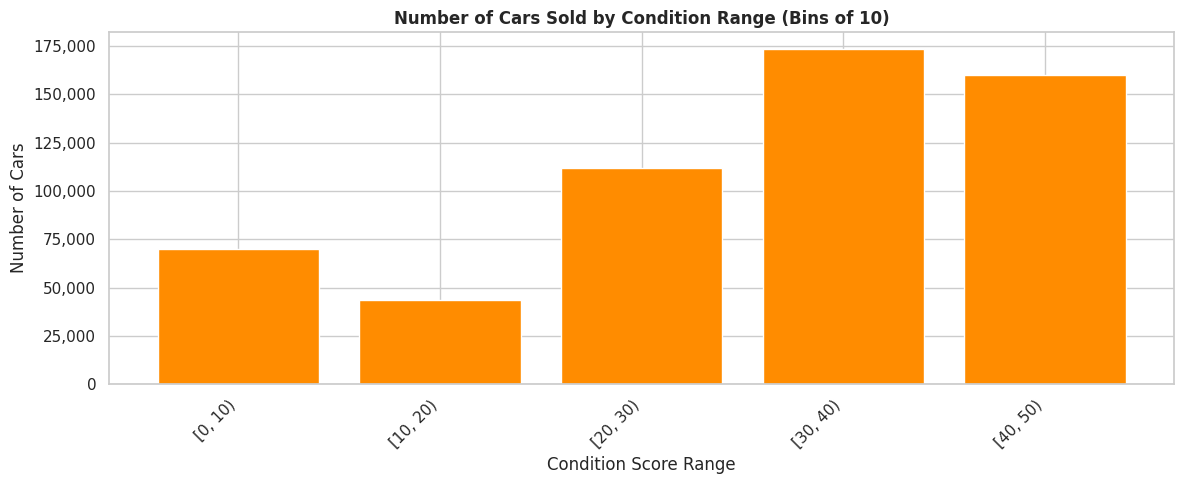


📌 Insights:
   • Most listed cars cluster in the 30–50 condition range — the bulk of the used market.
   • Very few cars appear at the extreme low end (0–10), likely write-offs or salvage.
   • The highest-condition cars (50+) are also relatively rare, representing near-new vehicles.
   • This bell-curve-like distribution is typical of used car market listings.



In [52]:
bins10 = range(0, cond_max + 1, 10)
df['cond_bin10'] = pd.cut(df['condition'], bins=list(bins10), right=False)

count_by_cond10 = (df.groupby('cond_bin10', observed=True)
                     .size()
                     .reset_index(name='count')
                     .dropna())

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(count_by_cond10['cond_bin10'].astype(str),
       count_by_cond10['count'],
       color='darkorange', edgecolor='white')
ax.set_title('Number of Cars Sold by Condition Range (Bins of 10)', fontweight='bold')
ax.set_xlabel('Condition Score Range')
ax.set_ylabel('Number of Cars')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_count_by_condition10.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
📌 Insights:
   • Most listed cars cluster in the 30–50 condition range — the bulk of the used market.
   • Very few cars appear at the extreme low end (0–10), likely write-offs or salvage.
   • The highest-condition cars (50+) are also relatively rare, representing near-new vehicles.
   • This bell-curve-like distribution is typical of used car market listings.
""")

### 3.7 Box Plot: Selling Price Distribution by Color

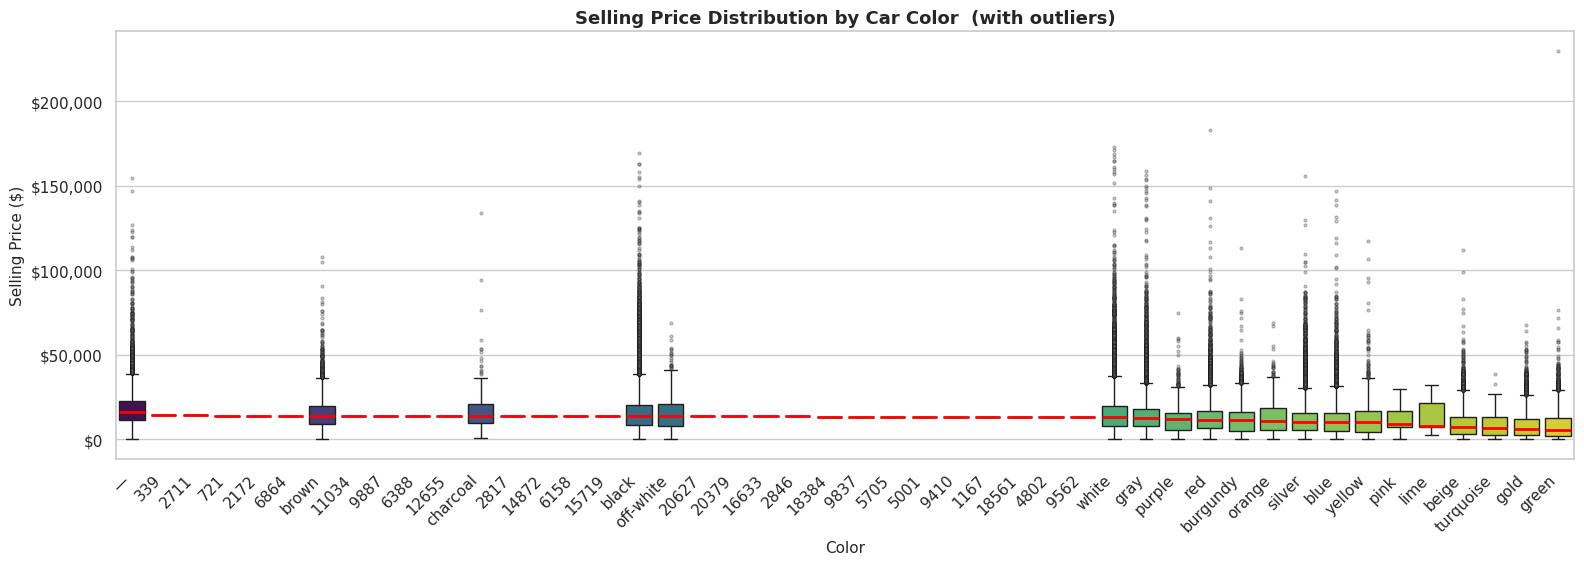


📌 Insights (with outliers):
   • Extreme outliers exist across almost all colors — skewing the scale heavily.
   • White, black & silver have the widest spread — highest volume + varied models.
   • Rare colors (purple, pink) show narrower boxes due to fewer listings.
   → Outliers make it hard to compare medians visually. Removing them below.



In [55]:
import seaborn as sns

# ── Sort colors by median price ───────────────────────────────
color_order = (df.groupby('color')[price_col]
                 .median()
                 .sort_values(ascending=False)
                 .index.tolist())

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(x='color', y=price_col, data=df, ax=ax,
           order=color_order,
           palette='viridis', # Using a color palette for better visualization
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markersize=2,
                           markerfacecolor='grey', alpha=0.3))
ax.set_title('Selling Price Distribution by Car Color  (with outliers)',
             fontweight='bold', fontsize=13)
plt.suptitle('')
ax.set_xlabel('Color', fontsize=11)
ax.set_ylabel('Selling Price ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("""
📌 Insights (with outliers):
   • Extreme outliers exist across almost all colors — skewing the scale heavily.
   • White, black & silver have the widest spread — highest volume + varied models.
   • Rare colors (purple, pink) show narrower boxes due to fewer listings.
   → Outliers make it hard to compare medians visually. Removing them below.
""")

Outliers removed : 16,298  rows  (2.9%)


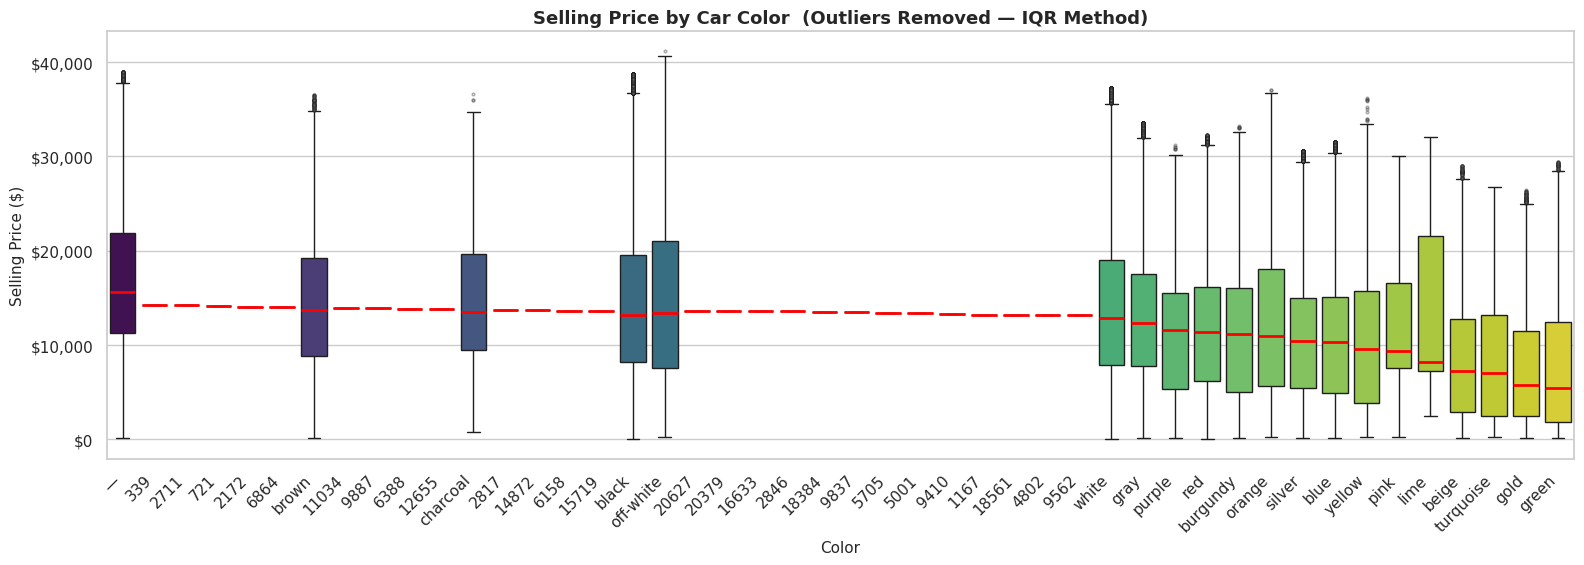


📌 Insights (outliers removed):
   • Much cleaner comparison — median lines are now clearly visible per color.
   • Black and white cars tend to have higher median prices across the board.
   • Silver/grey serve as the budget-friendly, high-volume segment.
   • Rare exotic colors show high variance — price driven by make/model, not color.
   • IQR method removed extreme auction/salvage outliers distorting the distribution.



In [58]:
# ── Remove outliers via IQR per color group ───────────────────
def remove_outliers_iqr(grp):
    Q1, Q3 = grp[price_col].quantile(0.25), grp[price_col].quantile(0.75)
    IQR = Q3 - Q1
    return grp[(grp[price_col] >= Q1 - 1.5*IQR) &
               (grp[price_col] <= Q3 + 1.5*IQR)]

df_clean = df.groupby('color', group_keys=False).apply(remove_outliers_iqr)
removed  = len(df) - len(df_clean)
print(f"Outliers removed : {removed:,}  rows  ({removed/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(x='color', y=price_col, data=df_clean, ax=ax,
                 order=color_order,
                 palette='viridis', # Using a color palette for better visualization
                 medianprops=dict(color='red', linewidth=2),
                 flierprops=dict(marker='o', markersize=2, markerfacecolor='grey', alpha=0.3))
ax.set_title('Selling Price by Car Color  (Outliers Removed — IQR Method)',
             fontweight='bold', fontsize=13)
plt.suptitle('')
ax.set_xlabel('Color', fontsize=11)
ax.set_ylabel('Selling Price ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("""
📌 Insights (outliers removed):
   • Much cleaner comparison — median lines are now clearly visible per color.
   • Black and white cars tend to have higher median prices across the board.
   • Silver/grey serve as the budget-friendly, high-volume segment.
   • Rare exotic colors show high variance — price driven by make/model, not color.
   • IQR method removed extreme auction/salvage outliers distorting the distribution.
""")

---
## ✅ Analysis Complete!

| Section | Coverage |
|---------|----------|
| **1. Data Ingestion** | Load · Inspect · Shape · Dtypes · Nulls · Deduplication |
| **2. DataFrame Queries** | Q 2.1 → 2.12 (all 12 queries) |
| **3. Visualizations** | 7 charts with written insights |

> 💡 **Tip:** Run each cell sequentially from top to bottom for best results.